# Citation Verification Signal – Evaluation

This notebook evaluates the **Citation Verification** signal used in the
multi-signal hallucination detection system.

The signal verifies:
- Whether cited document IDs exist in the provided context
- Whether numeric claims are supported by cited documents

The goal is to assess how well the citation signal:
- Detects fabricated citations
- Penalizes unsupported numeric statistics
- Behaves across different hallucination types

This analysis is **offline and documentation-only** and does not affect runtime logic.


Imports & Setup 

In [7]:
import json
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

from src.detection.similarity_check import SimilarityChecker

e:\llm-hallucination-detector\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset Description

We use a labeled evaluation dataset containing 90 question–answer pairs.

Each example consists of:
- A question
- A list of context documents (array of `{doc_id, text}`)
- A generated answer
- A ground-truth label (`valid` or `hallucinated`)
- A hallucination type annotation

The dataset contains both valid answers and multiple hallucination types,
including fabricated statistics, wrong entities, negations, fake citations,
and off-topic responses.

In [11]:
with open("../data/preliminary_hallucination_dataset.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.head()


,question_id,question,context,answer,label,hallucination_type
0,1,Does metformin reduce hepatic glucose producti...,"[{'doc_id': 'doc1', 'text': 'Metformin lowers ...",Yes. Metformin reduces hepatic glucose product...,valid,none
1,2,Is smoking a major risk factor for lung cancer?,"[{'doc_id': 'doc1', 'text': 'Smoking is the le...",Yes. Smoking is a major risk factor for lung c...,valid,none
2,3,Do statins inhibit HMG-CoA reductase?,"[{'doc_id': 'doc1', 'text': 'Statins inhibit H...",Yes. Statins inhibit HMG-CoA reductase [doc1].,valid,none
3,4,Does insulin lower blood glucose levels?,"[{'doc_id': 'doc1', 'text': 'Insulin lowers bl...",Yes. Insulin lowers blood glucose levels [doc1].,valid,none
4,5,Is hypertension associated with increased stro...,"[{'doc_id': 'doc1', 'text': 'Hypertension is a...",Yes. Hypertension is associated with increased...,valid,none


## Label Preprocessing

For evaluation, we convert labels into a binary format:
- 0 → valid answer
- 1 → hallucinated answer

In [9]:
df["label_binary"] = df["label"].map({
    "valid": 0,
    "hallucinated": 1
})


## Running the Citation Verification Signal

We apply the citation verification checker to each example and record:

-Normalized citation faithfulness score in 0,1, measuring how well the answer is structurally grounded in the provided context
-Binary hallucination prediction derived from the citation threshold (faithfulness_score < 0.7)
-Citation validity statistics, including the number of valid and invalid citations
-Numeric support indicators, capturing whether numeric claims in the answer are supported by cited documents

In [12]:
from src.detection.citation_check import citation_checker
import pandas as pd

checker = citation_checker

results = []

for row in data:
    output = checker.check(
        answer=row["answer"],
        context_docs=row["context"]
    )

    results.append({
        "question_id": row["question_id"],
        # citation signal outputs
        "faithfulness_score": output["faithfulness_score"],
        "citation_score": output["score"],  # same value, kept for consistency
        "predicted": int(not output["passed"]),  # 1 = hallucinated
        # ground truth
        "label": row["label"],
        "label_binary": 1 if row["label"] == "hallucinated" else 0,
        "hallucination_type": row.get("hallucination_type", "none"),
        # useful diagnostics
        "numeric_claim_present": output["metadata"]["numeric_claim_present"],
        "numeric_support_present": output["metadata"]["numeric_support_present"],
        "num_citations": len(output["citations_found"]),
        "num_invalid_citations": len(output["invalid_citations"]),
    })

res_df = pd.DataFrame(results)
res_df.head()


No citations found in answer
No citations found in answer


,question_id,faithfulness_score,citation_score,predicted,label,label_binary,hallucination_type,numeric_claim_present,numeric_support_present,num_citations,num_invalid_citations
0,1,1.0,1.0,0,valid,0,none,False,True,2,0
1,2,1.0,1.0,0,valid,0,none,False,False,2,0
2,3,1.0,1.0,0,valid,0,none,False,False,1,0
3,4,1.0,1.0,0,valid,0,none,False,False,1,0
4,5,1.0,1.0,0,valid,0,none,False,False,1,0


## Overall Classification Performance

We evaluate the semantic similarity signal as a binary classifier using:
- Precision
- Recall
- F1-score




In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

y_true = res_df["label_binary"]
y_pred = res_df["predicted"]

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")


Precision: 1.000
Recall:    0.400
F1-score:  0.571


## Confusion Matrix

The confusion matrix highlights false positives and false negatives.


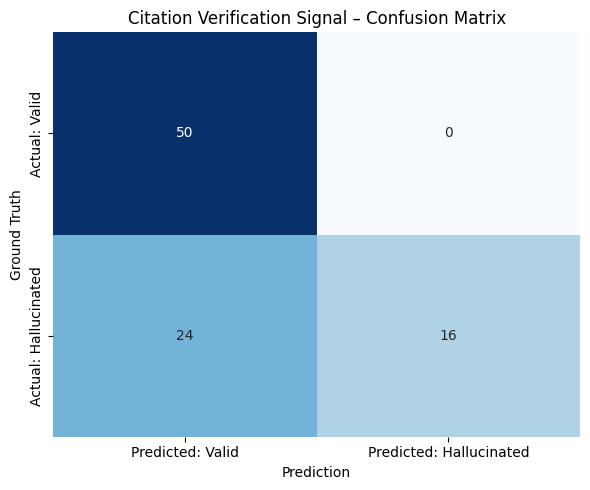

In [15]:


conf_matrix = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    conf_matrix,
    index=["Actual: Valid", "Actual: Hallucinated"],
    columns=["Predicted: Valid", "Predicted: Hallucinated"]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Citation Verification Signal – Confusion Matrix")
plt.ylabel("Ground Truth")
plt.xlabel("Prediction")
plt.tight_layout()
plt.show()


## ROC-AUC Analysis

We evaluate the citation verification signal using ROC–AUC to assess how well the
continuous faithfulness score separates valid answers from hallucinated ones
across all possible thresholds.

Positive class (1) → hallucinated

Negative class (0) → valid

Score used → 1 − faithfulness_score
(higher values indicate higher hallucination likelihood)

This transformation aligns the citation signal with the other hallucination scores
used in the system.


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

# Ground truth
y_true = res_df["label_binary"]

# Convert faithfulness → hallucination score
y_scores = 1.0 - res_df["faithfulness_score"]

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc = roc_auc_score(y_true, y_scores)

print(f"ROC-AUC: {auc:.3f}")


ROC-AUC: 0.700


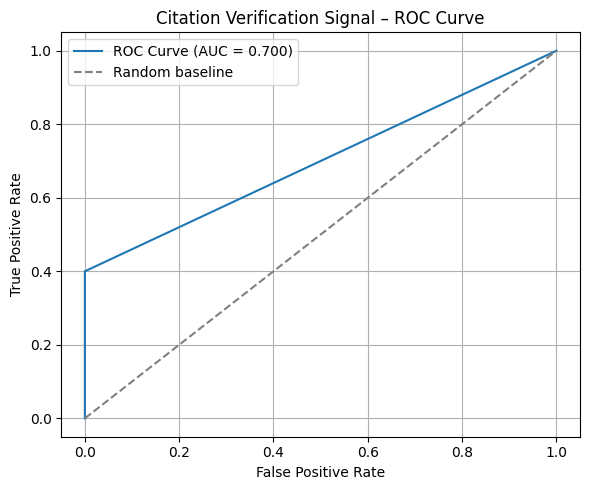

In [17]:

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Citation Verification Signal – ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Performance by Hallucination Type

We analyze recall per hallucination type to understand
which error categories Citation check can detect.


In [18]:
type_recall = (
    res_df[res_df["label_binary"] == 1]
    .groupby("hallucination_type")["predicted"]
    .mean()
    .sort_values(ascending=False)
)

type_recall


hallucination_type
off_topic          1.0
fake_citation      1.0
fabricated_stat    0.9
added_fact         0.0
negation           0.0
wrong_entity       0.0
Name: predicted, dtype: float64

## Threshold Sensitivity Analysis


In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.linspace(0.4, 0.9, 25)
rows = []

y_true = res_df["label_binary"]

for t in thresholds:
    # Predict hallucination if citation faithfulness is below threshold
    preds = (res_df["faithfulness_score"] < t).astype(int)

    rows.append({
        "threshold": t,
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    })

th_df = pd.DataFrame(rows)
th_df.head()


,threshold,precision,recall,f1
0,0.400000,1.0,0.125,0.222222
1,0.420833,1.0,0.125,0.222222
2,0.441667,1.0,0.125,0.222222
3,0.462500,1.0,0.125,0.222222
4,0.483333,1.0,0.125,0.222222


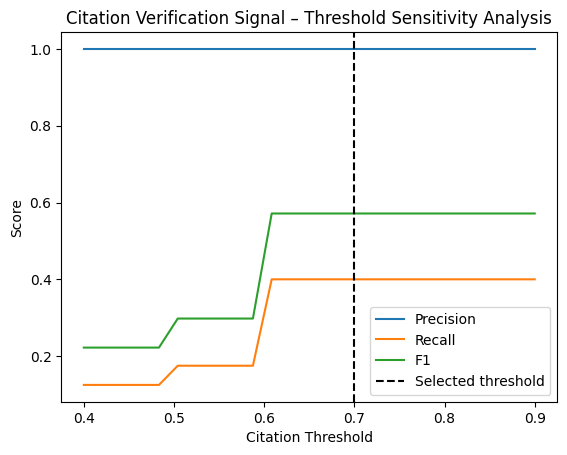

In [21]:
plt.plot(th_df["threshold"], th_df["precision"], label="Precision")
plt.plot(th_df["threshold"], th_df["recall"], label="Recall")
plt.plot(th_df["threshold"], th_df["f1"], label="F1")

plt.axvline(0.7, color="black", linestyle="--", label="Selected threshold")
plt.xlabel("Citation Threshold")
plt.ylabel("Score")
plt.title("Citation Verification Signal – Threshold Sensitivity Analysis")
plt.legend()
plt.show()


## Error Analysis


In [22]:
false_positives = res_df[(y_true == 0) & (y_pred == 1)]
false_negatives = res_df[(y_true == 1) & (y_pred == 0)]

len(false_positives), len(false_negatives)


(0, 24)

## Calibration Analysis
The citation faithfulness score takes on a small set of discrete values (0.0, 0.6, 1.0) due to its rule-based design. Calibration analysis shows that low scores (≤ 0.6) are strongly associated with hallucinated outputs, while high scores (1.0) correspond mostly to valid answers. Empty bins indicate score ranges that do not occur in practice and are expected given the deterministic scoring scheme.

In [24]:
res_df.groupby(pd.cut(res_df["faithfulness_score"], bins=5))["label_binary"].mean()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22860\1361717596.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res_df.groupby(pd.cut(res_df["faithfulness_score"], bins=5))["label_binary"].mean()


faithfulness_score
(-0.001, 0.2]    1.000000
(0.2, 0.4]            NaN
(0.4, 0.6]       1.000000
(0.6, 0.8]            NaN
(0.8, 1.0]       0.324324
Name: label_binary, dtype: float64